### Notebook 3 — Spot Arrays, GS and WGS

### Goal

Use the Meadowlark SLM and Allied Vision camera together to progress from
simple multi-spot smoke tests to proper GS/WGS holography.

### Stage A — Dummy spot arrays
1. Connect SLM and camera.
2. Restore camera exposure and 1600×1600 ROI.
3. Generate a simple non-optimized 3×3 phase pattern.
4. Display it on the SLM.
5. Acquire the resulting pattern on the camera.
6. Repeat for a simple 10×10 pattern.

These arrays are only optical smoke tests.
Uniformity is not expected to be good.

### Stage B — Fourier calibration
Determine the experimental mapping

SLM k-space
    ↓
camera pixel coordinates

using the slmsuite FourierSLM calibration tools.

### Stage C — Proper 3×3 holography
1. Define a calibrated 3×3 target.
2. Run Gerchberg-Saxton (GS).
3. Display the phase on the SLM.
4. Measure the nine camera spot powers.
5. Calculate uniformity.
6. Run computational WGS-Kim.
7. Measure the nine powers again.
8. Compare GS and WGS quantitatively.

Later:
- experimental/camera-feedback WGS
- larger optimized arrays
- zero-padding studies

In [22]:
# Cell 1 — Imports and environment check

import sys
import time
from pathlib import Path
from importlib.metadata import version

import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

# Sharper inline plots in Jupyter
set_matplotlib_formats("retina")

# Kunal's physics plotting style
plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)

import slmsuite

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.alliedvision import AlliedVision

from slmsuite.holography.toolbox import convert_vector
from slmsuite.holography.toolbox.phase import blaze

# We will use these later for the proper holography section.
from slmsuite.hardware.cameraslms import FourierSLM
from slmsuite.holography.algorithms import SpotHologram
from slmsuite.holography import analysis


print("=== Notebook 3 environment ===")
print("Python executable :", sys.executable)
print("Python version    :", sys.version.split()[0])
print("slmsuite         :", version("slmsuite"))
print("NumPy            :", np.__version__)
print("VmbPy            :", version("VmbPy"))

print("\nImports successful.")

=== Notebook 3 environment ===
Python executable : c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\python.exe
Python version    : 3.12.10
slmsuite         : 0.4.1
NumPy            : 2.5.1
VmbPy            : 1.2.2

Imports successful.


In [23]:
# Cell 2 — Hardware configuration and persistent connections

from pathlib import Path

# ============================================================
# Known hardware configuration
# ============================================================

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\LUT from Fan"
    r"\759nm_roomtemp_global\759nm_roomtemp_global"
    r"\759nm_rommtemp_global.lut"
)

CAMERA_SERIAL = "015C2"

# Camera operating point established in Notebook 2
CAMERA_EXPOSURE_S = 0.6e-3

# Hardware ROI:
# (x_offset, width, y_offset, height)
CAMERA_ROI = (1948, 1600, 1036, 1600)


print("=== Configuration ===")
print("SDK :", SDK_PATH)
print("LUT :", LUT_PATH)
print("Camera serial :", CAMERA_SERIAL)

assert SDK_PATH.exists(), "Meadowlark SDK path not found."
assert LUT_PATH.exists(), "LUT file not found."


# ============================================================
# Connect Allied Vision camera
# ============================================================

if "cam" not in globals() or cam is None:

    print("\nConnecting camera...")

    cam = AlliedVision(
        serial=CAMERA_SERIAL,
        pitch_um=2.4,
        verbose=True,
    )

else:
    print("\nCamera object already exists — reusing it.")


# Camera operating settings
cam.set_exposure(CAMERA_EXPOSURE_S)

try:
    cam.cam.Gain.set(0.0)
except Exception:
    pass

# Restore the ROI established in Notebook 2.
cam.set_woi(CAMERA_ROI)


# ============================================================
# Connect Meadowlark SLM
# ============================================================

if "slm" not in globals() or slm is None:

    print("\nConnecting Meadowlark SLM...")

    slm = Meadowlark(
        slm_number=1,
        sdk_path=str(SDK_PATH),
        lut_path=str(LUT_PATH),
        wav_um=0.759,
        verbose=True,
    )

else:
    print("\nSLM object already exists — reusing it.")


# Start Notebook 3 from a known optical state.
slm.set_phase(None, settle=True)


# ============================================================
# Summary
# ============================================================

print("\n=== Camera ===")
print("Model       :", cam.cam.get_model())
print("Serial      :", cam.cam.get_serial())
print("WOI         :", cam.woi)
print("Exposure    :", f"{cam.get_exposure()*1e6:.3f} us")
print("Pixel pitch :", cam.pitch_um, "um")

print("\n=== SLM ===")
print("Name        :", slm.name)
print("Shape       :", slm.shape)
print("Bit depth   :", slm.bitdepth)
print("Wavelength  :", slm.wav_um, "um")
print("Pixel pitch :", slm.pitch_um, "um")

print("\nCamera and SLM ready.")

=== Configuration ===
SDK : C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK
LUT : C:\Users\admin\Desktop\Projects\SLM\LUT from Fan\759nm_roomtemp_global\759nm_roomtemp_global\759nm_rommtemp_global.lut
Camera serial : 015C2

Camera object already exists — reusing it.

SLM object already exists — reusing it.

=== Camera ===
Model       : 1800 U-2050m
Serial      : 015C2
WOI         : (1948, 1600, 1036, 1600)
Exposure    : 607.181 us
Pixel pitch : [2.4 2.4] um

=== SLM ===
Name        : Meadowlark HDMI
Shape       : (1200, 1920)
Bit depth   : 8
Wavelength  : 0.759 um
Pixel pitch : [8. 8.] um

Camera and SLM ready.


In [24]:
# Cell 3 — Camera positioning / focus test
#
# 1. Flat SLM
# 2. Recover beam in known-good 1600x1600 ROI
# 3. Find its actual position
# 4. Center a 400x400 ROI on it
# 5. Launch live viewer for camera z adjustment

import time
import numpy as np

# ------------------------------------------------------------
# Flat SLM
# ------------------------------------------------------------

try:
    cam.live(activate=False)
except Exception:
    pass

slm.set_phase(None, settle=True)

# ------------------------------------------------------------
# Recover beam in known-good large ROI
# ------------------------------------------------------------

LARGE_ROI = (1948, 1600, 1036, 1600)

print("Setting large search ROI...")
cam.set_woi(LARGE_ROI)

time.sleep(0.3)

img_search = cam.get_image(
    timeout_s=2,
    transform=False,
)

search_y, search_x = np.unravel_index(
    np.argmax(img_search),
    img_search.shape,
)

print("\n=== Search image ===")
print("Shape      :", img_search.shape)
print("Max        :", img_search.max())
print("Peak x,y   :", (search_x, search_y))

# Convert local ROI coordinate -> full sensor coordinate
global_x = LARGE_ROI[0] + search_x
global_y = LARGE_ROI[2] + search_y

print("Global x,y :", (global_x, global_y))

# ------------------------------------------------------------
# Build a 400x400 ROI around the ACTUAL spot position
# ------------------------------------------------------------

FOCUS_W = 400
FOCUS_H = 400

# Offset increments are 2 pixels
focus_x0 = int(2 * round((global_x - FOCUS_W/2) / 2))
focus_y0 = int(2 * round((global_y - FOCUS_H/2) / 2))

FOCUS_ROI = (
    focus_x0,
    FOCUS_W,
    focus_y0,
    FOCUS_H,
)

print("\nSetting focus ROI:")
print(FOCUS_ROI)

cam.set_woi(FOCUS_ROI)

time.sleep(0.3)

# ------------------------------------------------------------
# Verify beam is inside new ROI
# ------------------------------------------------------------

img_focus = cam.get_image(
    timeout_s=2,
    transform=False,
)

focus_y, focus_x = np.unravel_index(
    np.argmax(img_focus),
    img_focus.shape,
)

print("\n=== Focus ROI ===")
print("Shape            :", img_focus.shape)
print("Max              :", img_focus.max())
print("Saturated pixels :", np.count_nonzero(img_focus == 255))
print("Peak x,y         :", (focus_x, focus_y))

# ------------------------------------------------------------
# Live viewer
# ------------------------------------------------------------

cam.live(
    activate=True,
    widgets=True,
    cmap="gray",
    min=0,
    max=255,
    scale=2,
    crosshair=True,
)

print("\nTurn Live ON.")
print("Translate camera along z until the spot is smallest.")

Setting large search ROI...

=== Search image ===
Shape      : (1600, 1600)
Max        : 255
Peak x,y   : (np.int64(940), np.int64(829))
Global x,y : (np.int64(2888), np.int64(1865))

Setting focus ROI:
(2688, 400, 1664, 400)

=== Focus ROI ===
Shape            : (400, 400)
Max              : 255
Saturated pixels : 367
Peak x,y         : (np.int64(197), np.int64(202))


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x03 \x00\x00\x03 \x08\x06\x00\x00\x00\xdbp\x06h\x00\…


Turn Live ON.
Translate camera along z until the spot is smallest.


=== Flat-phase reference ===
ROI              : (1948, 1600, 1036, 1600)
Image shape      : (1600, 1600)
Peak value       : 255
Saturated pixels : 390
Zero order x,y   : (np.int64(937), np.int64(830))
Acquisition time : 0.190 s


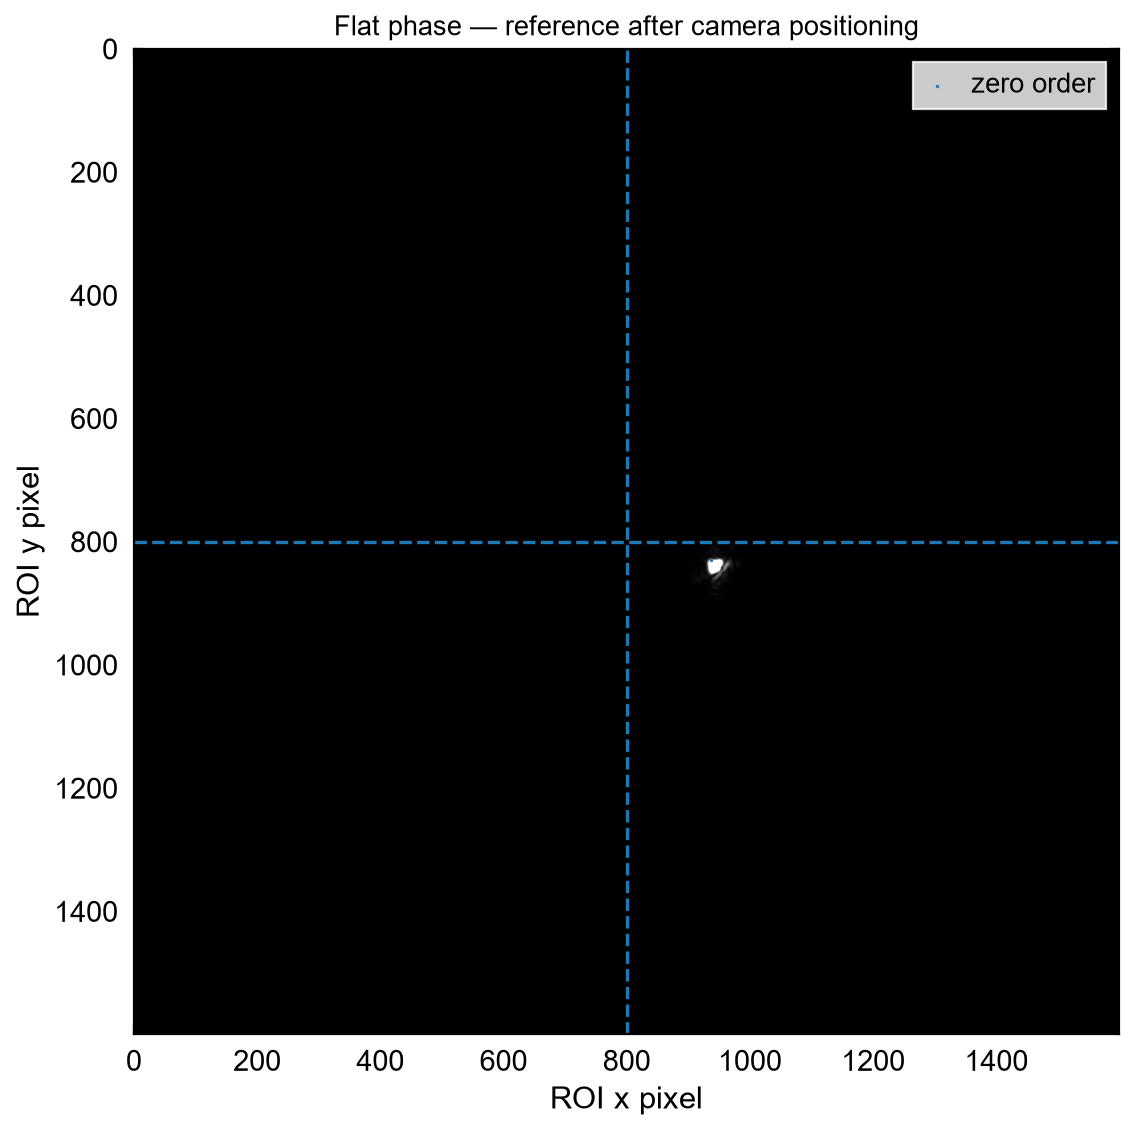

In [25]:
# Cell 4 — Flat-phase reference snapshot after camera positioning

import time
import numpy as np
import matplotlib.pyplot as plt

# Stop live acquisition first
try:
    cam.live(activate=False)
except Exception:
    pass

# ------------------------------------------------------------
# Restore normal working ROI
# ------------------------------------------------------------

WORKING_ROI = (1948, 1600, 1036, 1600)

cam.set_woi(WORKING_ROI)

time.sleep(0.3)

# ------------------------------------------------------------
# Flat phase on SLM
# ------------------------------------------------------------

slm.set_phase(
    None,
    settle=True,
)

# ------------------------------------------------------------
# Acquire one image
# ------------------------------------------------------------

t0 = time.perf_counter()

image_flat = cam.get_image(
    timeout_s=2,
    transform=False,
)

dt = time.perf_counter() - t0

# Find zeroth order
zero_y, zero_x = np.unravel_index(
    np.argmax(image_flat),
    image_flat.shape,
)

print("=== Flat-phase reference ===")
print("ROI              :", cam.woi)
print("Image shape      :", image_flat.shape)
print("Peak value       :", image_flat.max())
print("Saturated pixels :", np.count_nonzero(image_flat == 255))
print("Zero order x,y   :", (zero_x, zero_y))
print(f"Acquisition time : {dt:.3f} s")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.imshow(
    image_flat,
    cmap="gray",
    origin="upper",
)

plt.scatter(
    zero_x,
    zero_y,
    marker=".",
    s=1,
    label="zero order",
)

plt.axvline(image_flat.shape[1] / 2, linestyle="--")
plt.axhline(image_flat.shape[0] / 2, linestyle="--")

plt.xlabel("ROI x pixel")
plt.ylabel("ROI y pixel")
plt.title("Flat phase — reference after camera positioning")
plt.legend()

plt.show()

=== 3x3 target geometry ===
SLM shape         : (1200, 1920)
knm zero          : [960. 600.]
Array center knm  : (990, 600)
Array pitch knm   : (8, 5)

Requested spacing : 0.4 mrad
Requested carrier : 1.5 mrad x

SpotHologram created.
Number of spots : 9

Actual rounded spot positions [knm]:
[[982 990 998 982 990 998 982 990 998]
 [595 595 595 600 600 600 605 605 605]]


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:379: UserWarning: Hologram target shape (1200, 1920) is not a power of 2; consider using .get_padded_shape() to pad to powers of 2 and speed up FFT computation. While some FFT solvers support other prime powers (3, 5, 7, ...), literature suggests that GPU support is best for powers of 2.
  warnings.warn(


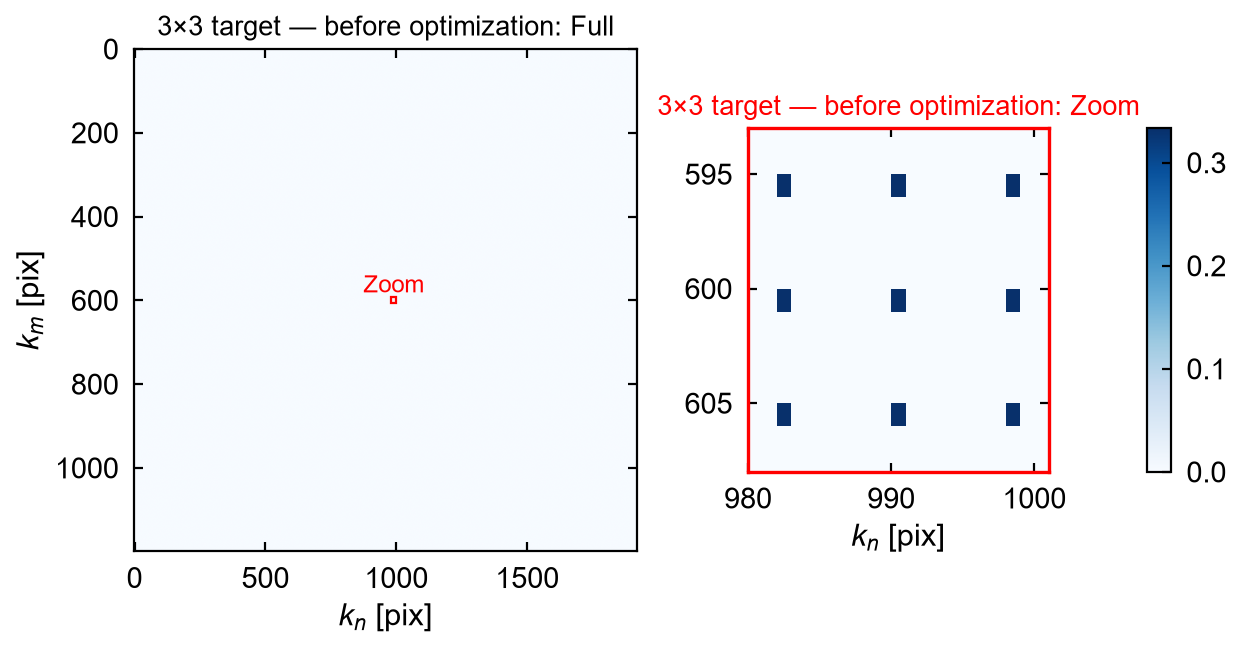


Running ordinary GS...


  0%|          | 0/10 [00:00<?, ?it/s]


GS completed in 3.68 s

=== GS phase ===
Shape : (1200, 1920)
Min   : 4.553795e-05
Max   : 6.2831516


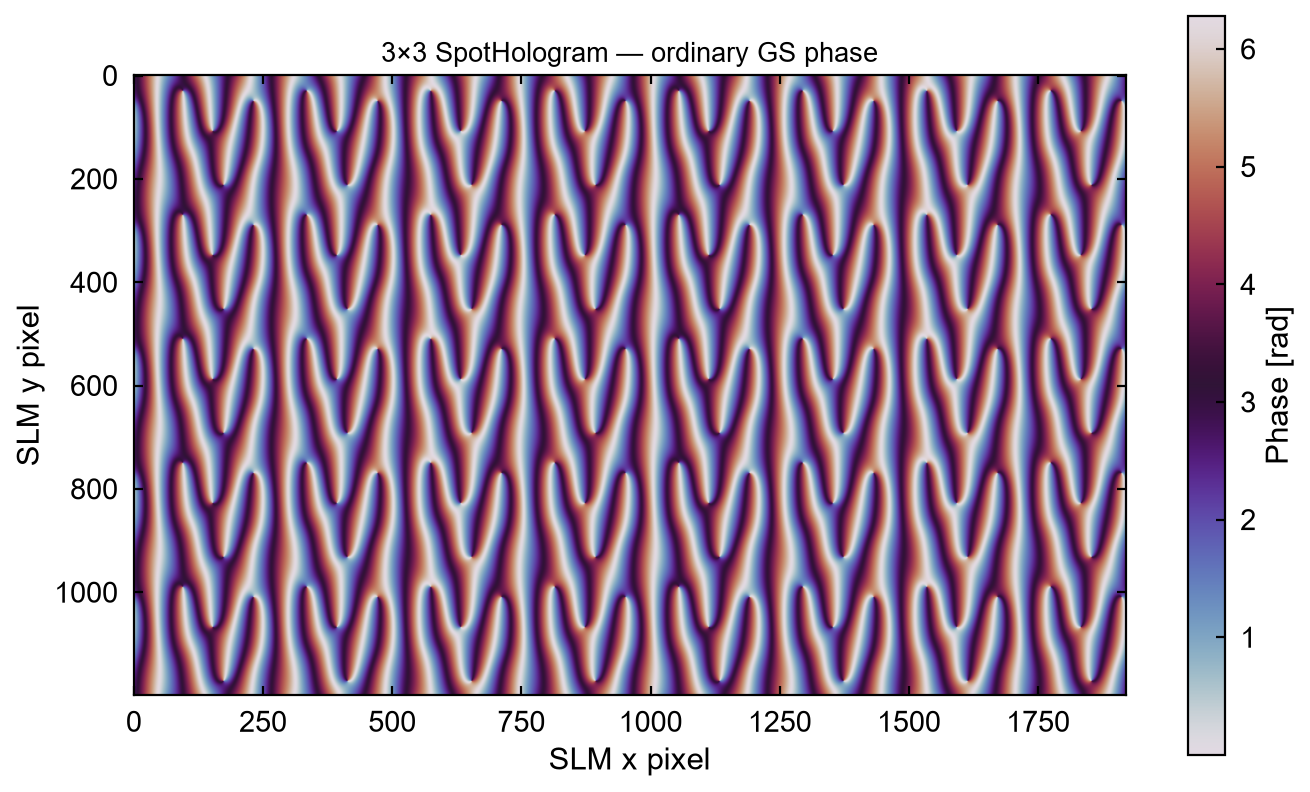


Writing 3x3 GS hologram to SLM...
SLM write completed in 0.330 s

=== Camera ===
Shape            : (1600, 1600)
Peak             : 255
Saturated pixels : 341


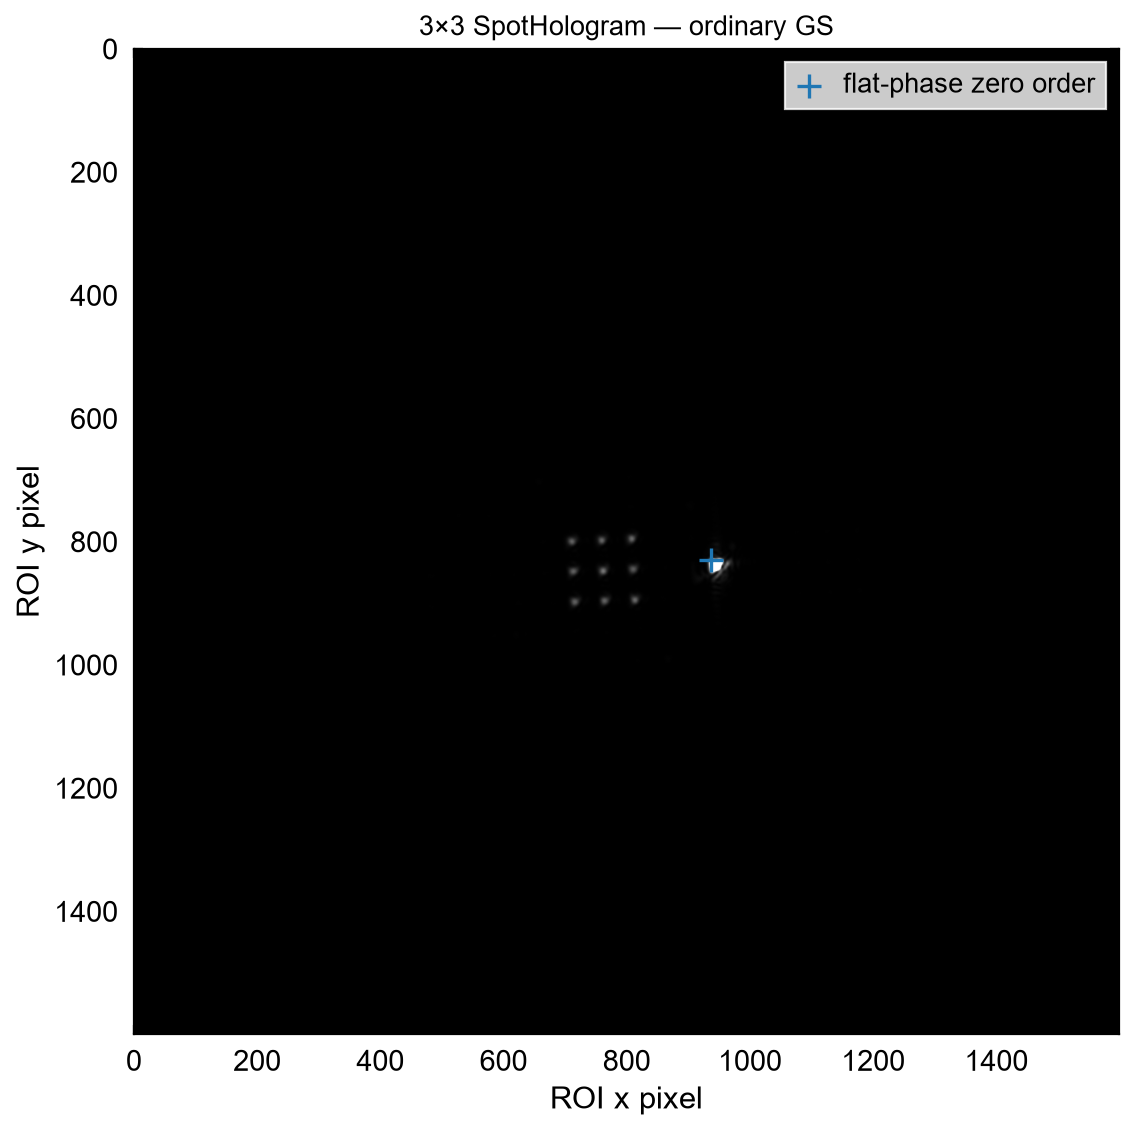

In [26]:
# Cell 5 — 3x3 SpotHologram using ordinary GS
#
# This is the BASELINE array.
# No WGS / homogenization yet.
#
# Target:
#   3 x 3 spots
#   ~0.40 mrad spacing
#   +1.50 mrad x carrier to separate array from zeroth order

import time
import numpy as np
import matplotlib.pyplot as plt

from slmsuite.holography.algorithms import SpotHologram


# ============================================================
# 1. Desired array geometry
# ============================================================

spacing_mrad = 0.40

carrier_x_mrad = 1.50
carrier_y_mrad = 0.00


# ============================================================
# 2. Convert our physical angular parameters -> knm
# ============================================================

# Zeroth order in computational Fourier space
knm_zero = np.ravel(
    convert_vector(
        (0.0, 0.0),
        from_units="mrad",
        to_units="knm",
        hardware=slm,
        shape=slm.shape,
    )
)

# Desired array center
knm_center = np.ravel(
    convert_vector(
        (carrier_x_mrad, carrier_y_mrad),
        from_units="mrad",
        to_units="knm",
        hardware=slm,
        shape=slm.shape,
    )
)

# One x-spacing step
knm_xstep = np.ravel(
    convert_vector(
        (spacing_mrad, 0.0),
        from_units="mrad",
        to_units="knm",
        hardware=slm,
        shape=slm.shape,
    )
)

# One y-spacing step
knm_ystep = np.ravel(
    convert_vector(
        (0.0, spacing_mrad),
        from_units="mrad",
        to_units="knm",
        hardware=slm,
        shape=slm.shape,
    )
)


# Convert absolute knm positions into pitch
pitch_x_knm = knm_xstep[0] - knm_zero[0]
pitch_y_knm = knm_ystep[1] - knm_zero[1]

# Use integer computational pixels so the 3x3 pitch stays uniform
array_pitch_knm = (
    int(round(abs(pitch_x_knm))),
    int(round(abs(pitch_y_knm))),
)

array_center_knm = (
    int(round(knm_center[0])),
    int(round(knm_center[1])),
)


print("=== 3x3 target geometry ===")
print("SLM shape         :", slm.shape)
print("knm zero          :", knm_zero)
print("Array center knm  :", array_center_knm)
print("Array pitch knm   :", array_pitch_knm)

print()
print("Requested spacing :", spacing_mrad, "mrad")
print("Requested carrier :", carrier_x_mrad, "mrad x")


# ============================================================
# 3. Create the 3x3 SpotHologram target
# ============================================================

holo_3x3_gs = SpotHologram.make_rectangular_array(
    shape=slm.shape,
    array_shape=(3, 3),
    array_pitch=array_pitch_knm,
    array_center=array_center_knm,
    basis="knm",
)

print("\nSpotHologram created.")
print("Number of spots :", holo_3x3_gs.spot_knm.shape[1])

print("\nActual rounded spot positions [knm]:")
print(holo_3x3_gs.spot_knm_rounded)


# ============================================================
# 4. Plot the requested target
# ============================================================

holo_3x3_gs.plot_farfield(
    source=holo_3x3_gs.target,
    title="3×3 target — before optimization",
    cbar=True,
)

plt.show()


# ============================================================
# 5. Ordinary Gerchberg-Saxton
# ============================================================

print("\nRunning ordinary GS...")

t0 = time.perf_counter()

holo_3x3_gs.optimize(
    method="GS",
    maxiter=10,
    stat_groups=["computational_spot"],
    verbose=True,
)

gs_time = time.perf_counter() - t0

print(f"\nGS completed in {gs_time:.2f} s")


# ============================================================
# 6. Retrieve calculated SLM phase
# ============================================================

phase_3x3_gs = holo_3x3_gs.get_phase()

print("\n=== GS phase ===")
print("Shape :", phase_3x3_gs.shape)
print("Min   :", phase_3x3_gs.min())
print("Max   :", phase_3x3_gs.max())


# ============================================================
# 7. Show calculated phase
# ============================================================

plt.figure(figsize=(10, 6))

plt.imshow(
    phase_3x3_gs,
    cmap="twilight",
    origin="upper",
)

plt.colorbar(label="Phase [rad]")
plt.xlabel("SLM x pixel")
plt.ylabel("SLM y pixel")
plt.title("3×3 SpotHologram — ordinary GS phase")

plt.show()


# ============================================================
# 8. Write GS phase to physical SLM
# ============================================================

print("\nWriting 3x3 GS hologram to SLM...")

t0 = time.perf_counter()

slm.set_phase(
    phase_3x3_gs,
    settle=True,
)

print(
    f"SLM write completed in "
    f"{time.perf_counter() - t0:.3f} s"
)


# ============================================================
# 9. Take one camera snapshot
# ============================================================

image_3x3_gs = cam.get_image(
    timeout_s=2,
    transform=False,
)

print("\n=== Camera ===")
print("Shape            :", image_3x3_gs.shape)
print("Peak             :", image_3x3_gs.max())
print(
    "Saturated pixels :",
    np.count_nonzero(image_3x3_gs == 255),
)


# ============================================================
# 10. Display camera image
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(
    image_3x3_gs,
    cmap="gray",
    origin="upper",
)

# Zeroth-order position measured in Cell 4
plt.scatter(
    zero_x,
    zero_y,
    marker="+",
    s=120,
    label="flat-phase zero order",
)

plt.xlabel("ROI x pixel")
plt.ylabel("ROI y pixel")
plt.title("3×3 SpotHologram — ordinary GS")

plt.legend()
plt.show()

=== 10x10 target geometry ===
SLM shape         : (1200, 1920)
knm zero          : [960. 600.]
Array center knm  : (1021, 600.5)
Array pitch knm   : (8, 5)

Requested spacing : 0.4 mrad
Requested carrier : 3.0 mrad x

Approx x-angle range : 1.2 to 4.8 mrad
Approx y-angle range : -1.8 to 1.8 mrad

SpotHologram created.
Number of spots : 100
spot_knm shape  : (2, 100)


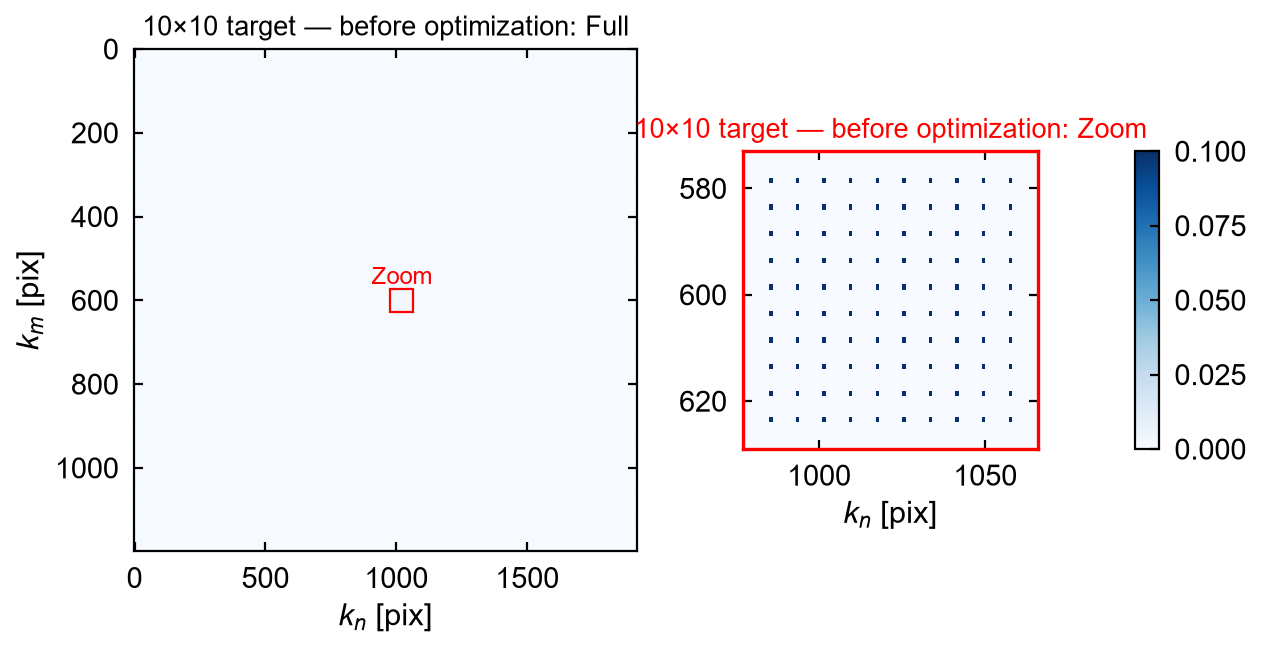


Running ordinary GS for 10x10...


  0%|          | 0/10 [00:00<?, ?it/s]


GS completed in 3.28 s

=== GS phase ===
Shape : (1200, 1920)
Min   : 2.3841858e-07
Max   : 6.283184


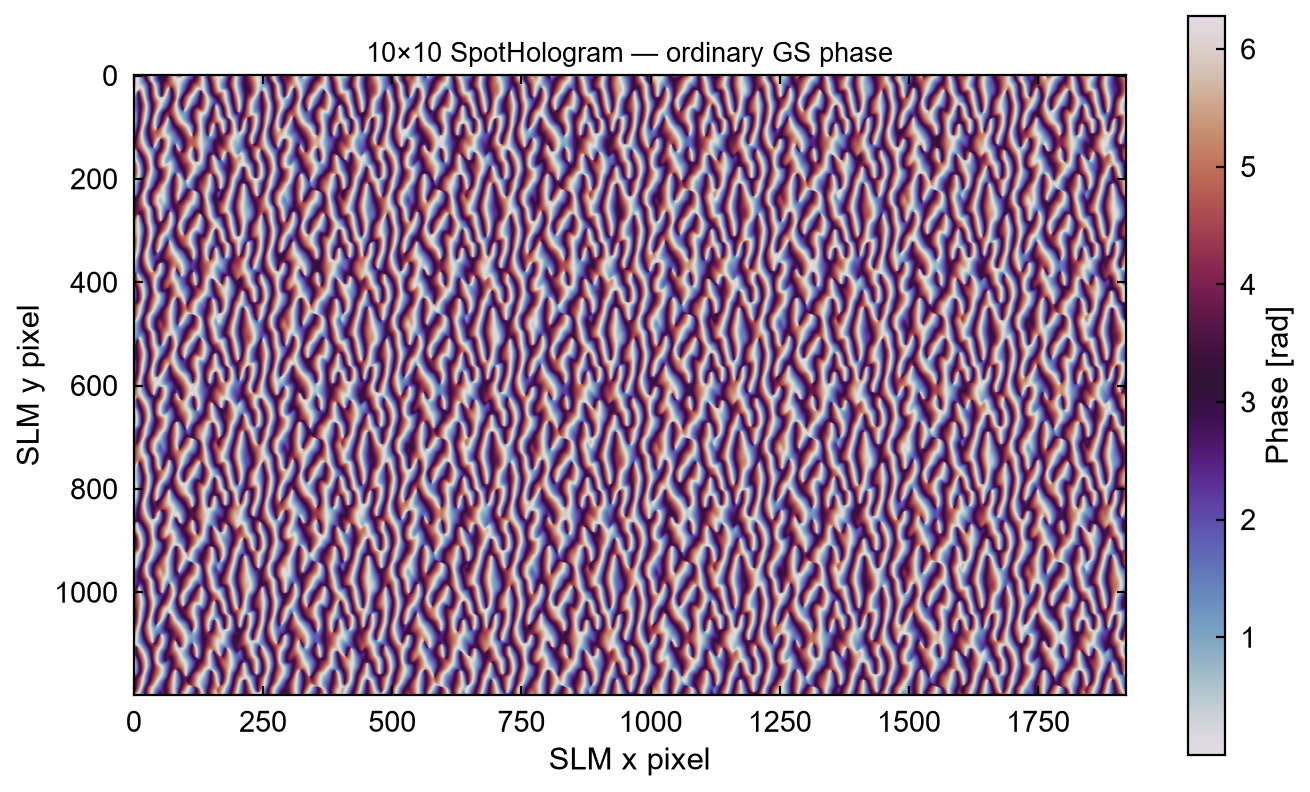


Writing 10x10 GS hologram to SLM...
SLM write completed in 0.329 s

=== Camera ===
Shape            : (1600, 1600)
Peak             : 255
Saturated pixels : 323
Acquisition time : 0.191 s


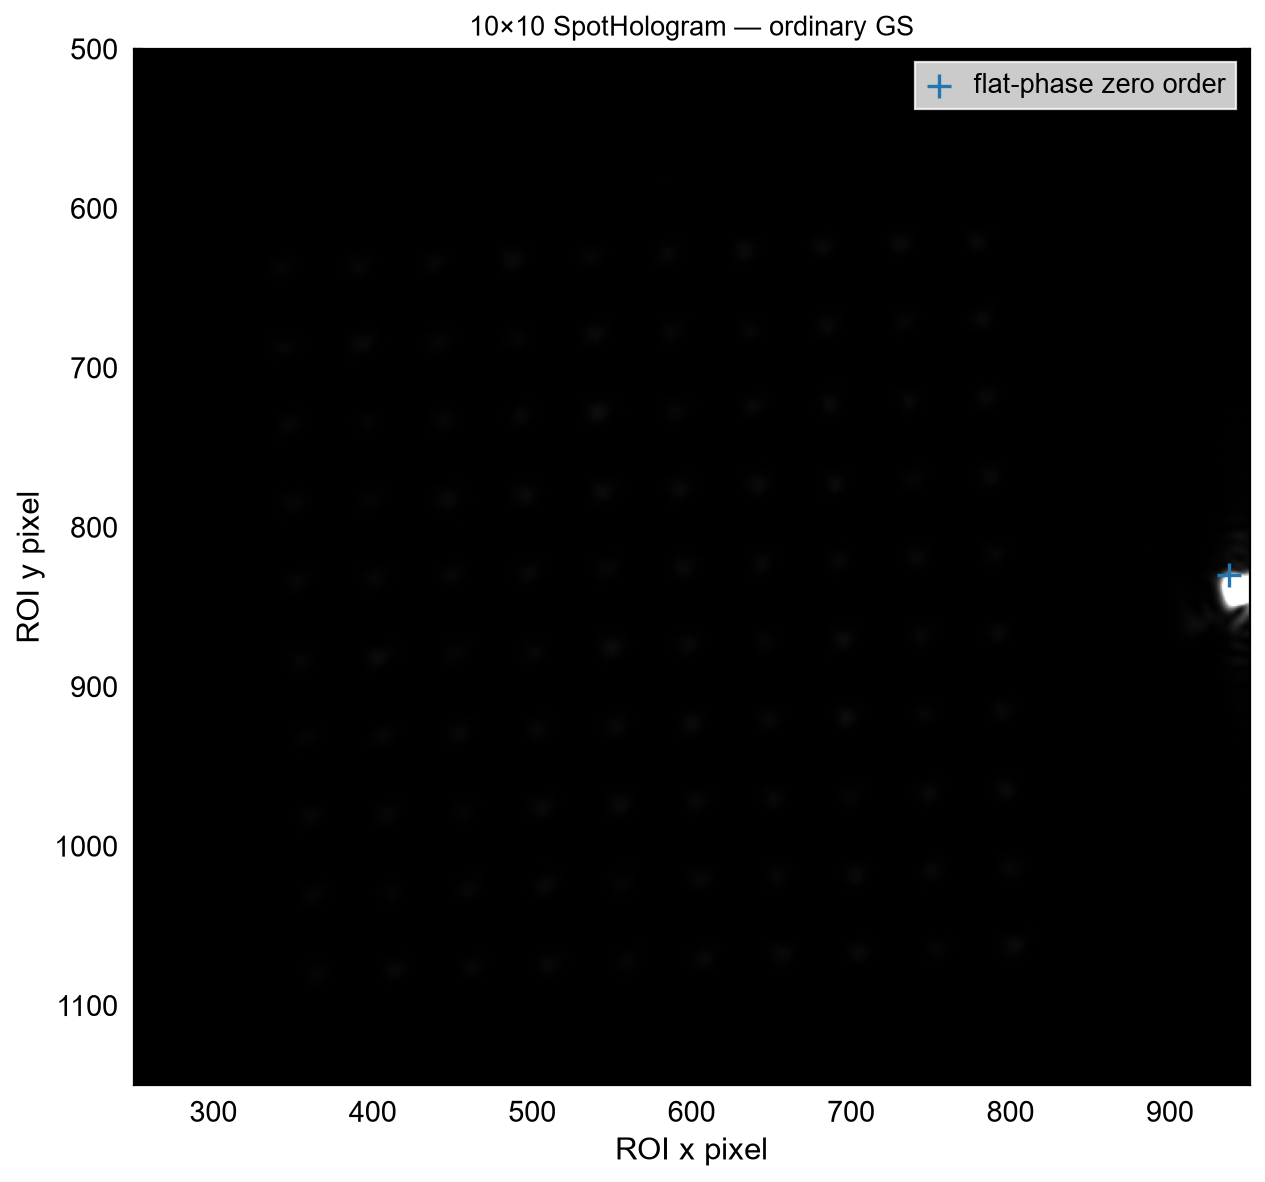

In [27]:
# Cell 6 — 10x10 SpotHologram using ordinary GS
#
# BASELINE 10x10 array.
# No WGS / homogenization yet.

import time
import numpy as np
import matplotlib.pyplot as plt

from slmsuite.holography.algorithms import SpotHologram


# ============================================================
# 1. Desired physical angular geometry
# ============================================================

spacing_mrad_10 = 0.40

carrier_x_mrad_10 = 3.00
carrier_y_mrad_10 = 0.00


# ============================================================
# 2. Convert physical angles -> computational knm coordinates
# ============================================================

# Computational position corresponding to zero diffraction angle.
knm_zero_10 = np.ravel(
    convert_vector(
        (0.0, 0.0),
        from_units="mrad",
        to_units="knm",
        hardware=slm,
        shape=slm.shape,
    )
)

# Computational position of the CENTER of the 10x10 array.
knm_center_10 = np.ravel(
    convert_vector(
        (carrier_x_mrad_10, carrier_y_mrad_10),
        from_units="mrad",
        to_units="knm",
        hardware=slm,
        shape=slm.shape,
    )
)

# Computational displacement corresponding to one 0.40 mrad x step.
knm_xstep_10 = np.ravel(
    convert_vector(
        (spacing_mrad_10, 0.0),
        from_units="mrad",
        to_units="knm",
        hardware=slm,
        shape=slm.shape,
    )
)

# Computational displacement corresponding to one 0.40 mrad y step.
knm_ystep_10 = np.ravel(
    convert_vector(
        (0.0, spacing_mrad_10),
        from_units="mrad",
        to_units="knm",
        hardware=slm,
        shape=slm.shape,
    )
)


# ============================================================
# 3. Extract integer x/y pitch for SpotHologram
# ============================================================

pitch_x_knm_10 = knm_xstep_10[0] - knm_zero_10[0]
pitch_y_knm_10 = knm_ystep_10[1] - knm_zero_10[1]

array_pitch_knm_10 = (
    int(round(abs(pitch_x_knm_10))),
    int(round(abs(pitch_y_knm_10))),
)

array_center_knm_10 = (
    int(round(knm_center_10[0])),
    round(knm_center_10[1]) + 0.5,
)


# ============================================================
# 4. Print geometry before creating hologram
# ============================================================

print("=== 10x10 target geometry ===")

print("SLM shape         :", slm.shape)
print("knm zero          :", knm_zero_10)
print("Array center knm  :", array_center_knm_10)
print("Array pitch knm   :", array_pitch_knm_10)

print()
print("Requested spacing :", spacing_mrad_10, "mrad")
print("Requested carrier :", carrier_x_mrad_10, "mrad x")

print()
print(
    "Approx x-angle range :",
    carrier_x_mrad_10 - 4.5 * spacing_mrad_10,
    "to",
    carrier_x_mrad_10 + 4.5 * spacing_mrad_10,
    "mrad"
)

print(
    "Approx y-angle range :",
    -4.5 * spacing_mrad_10,
    "to",
    +4.5 * spacing_mrad_10,
    "mrad"
)


# ============================================================
# 5. Create 10x10 SpotHologram target
# ============================================================

holo_10x10_gs = SpotHologram.make_rectangular_array(
    shape=slm.shape,
    array_shape=(10, 10),
    array_pitch=array_pitch_knm_10,
    array_center=array_center_knm_10,
    basis="knm",
)


# ============================================================
# 6. Inspect target
# ============================================================

print("\nSpotHologram created.")

print(
    "Number of spots :",
    holo_10x10_gs.spot_knm.shape[1]
)

print(
    "spot_knm shape  :",
    holo_10x10_gs.spot_knm.shape
)


# ============================================================
# 7. Plot requested Fourier-plane target
# ============================================================

holo_10x10_gs.plot_farfield(
    source=holo_10x10_gs.target,
    title="10×10 target — before optimization",
    cbar=True,
)

plt.show()


# ============================================================
# 8. Run ordinary Gerchberg-Saxton
# ============================================================

print("\nRunning ordinary GS for 10x10...")

t0 = time.perf_counter()

holo_10x10_gs.optimize(
    method="GS",
    maxiter=10,
    verbose=True,
)

gs_time_10 = time.perf_counter() - t0

print(
    f"\nGS completed in "
    f"{gs_time_10:.2f} s"
)


# ============================================================
# 9. Retrieve optimized SLM phase
# ============================================================

phase_10x10_gs = holo_10x10_gs.get_phase()

print("\n=== GS phase ===")

print(
    "Shape :",
    phase_10x10_gs.shape
)

print(
    "Min   :",
    phase_10x10_gs.min()
)

print(
    "Max   :",
    phase_10x10_gs.max()
)


# ============================================================
# 10. Plot SLM phase mask
# ============================================================

plt.figure(figsize=(10, 6))

plt.imshow(
    phase_10x10_gs,
    cmap="twilight",
    origin="upper",
)

plt.colorbar(
    label="Phase [rad]"
)

plt.xlabel(
    "SLM x pixel"
)

plt.ylabel(
    "SLM y pixel"
)

plt.title(
    "10×10 SpotHologram — ordinary GS phase"
)

plt.show()


# ============================================================
# 11. Write phase to physical SLM
# ============================================================

print(
    "\nWriting 10x10 GS hologram to SLM..."
)

t0 = time.perf_counter()

slm.set_phase(
    phase_10x10_gs,
    settle=True,
)

slm_write_time_10 = time.perf_counter() - t0

print(
    f"SLM write completed in "
    f"{slm_write_time_10:.3f} s"
)


# ============================================================
# 12. Acquire one camera image
# ============================================================

t0 = time.perf_counter()

image_10x10_gs = cam.get_image(
    timeout_s=2,
    transform=False,
)

camera_time_10 = time.perf_counter() - t0

print("\n=== Camera ===")

print(
    "Shape            :",
    image_10x10_gs.shape
)

print(
    "Peak             :",
    image_10x10_gs.max()
)

print(
    "Saturated pixels :",
    np.count_nonzero(
        image_10x10_gs == 255
    )
)

print(
    f"Acquisition time : "
    f"{camera_time_10:.3f} s"
)


# ============================================================
# 13. Plot camera image
# ============================================================

plt.figure(figsize=(9, 9))

plt.imshow(
    image_10x10_gs,
    cmap="gray",
    origin="upper",
)

# Zeroth-order position measured with flat phase in Cell 4.
plt.scatter(
    zero_x,
    zero_y,
    marker="+",
    s=120,
    label="flat-phase zero order",
)

# Zoom around region where we expect the 10x10 array.
plt.xlim(
    250,
    950
)

plt.ylim(
    1150,
    500
)

plt.xlabel(
    "ROI x pixel"
)

plt.ylabel(
    "ROI y pixel"
)

plt.title(
    "10×10 SpotHologram — ordinary GS"
)

plt.legend()

plt.show()

=== Camera exposure ===
Requested : 3.600 ms
Actual    : 3.605 ms
=== BEFORE homogenization — ARRAY ONLY ===
Crop shape        : (540, 560)
Peak in array     : 87
Saturated pixels : 0


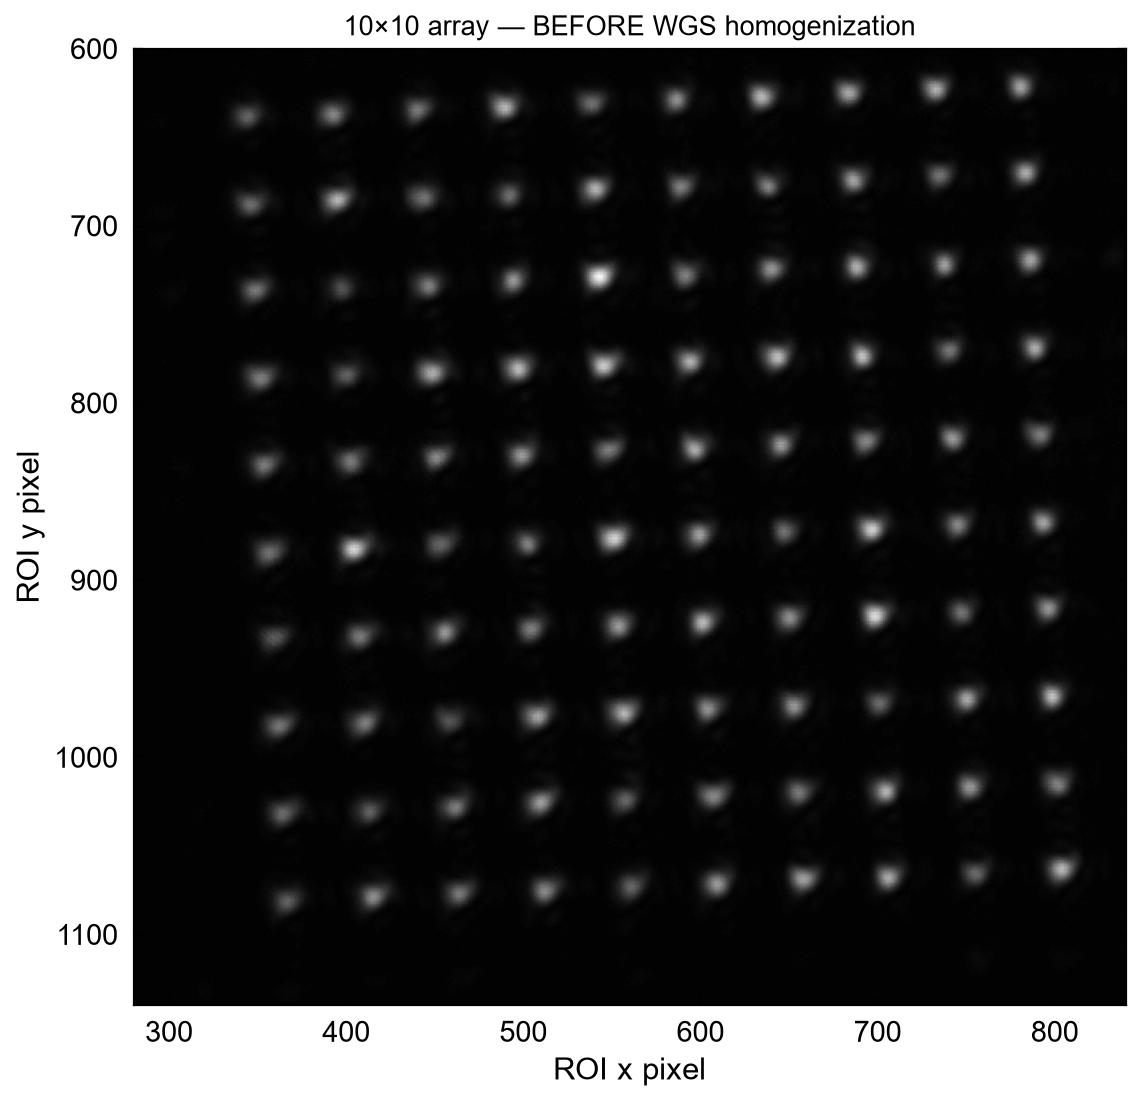

In [28]:
# Cell 7 — Camera exposure + BEFORE-homogenization image
#
# The 10x10 ordinary-GS hologram from Cell 6 should still be on the SLM.

import time
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Increase camera exposure
# ============================================================

EXPOSURE_MS = 3.6

cam.set_exposure(
    EXPOSURE_MS * 1e-3
)

actual_exposure_s = cam.get_exposure()

print("=== Camera exposure ===")
print(
    f"Requested : {EXPOSURE_MS:.3f} ms"
)
print(
    f"Actual    : {actual_exposure_s * 1e3:.3f} ms"
)


# ============================================================
# 2. Make sure the ordinary-GS 10x10 phase is on the SLM
# ============================================================

slm.set_phase(
    phase_10x10_gs,
    settle=True,
)

# ============================================================
# 3. Acquire BEFORE-homogenization image
# ============================================================

image_10x10_before_full = cam.get_image(
    timeout_s=2,
    transform=False,
)


# ============================================================
# 4. Crop ONLY the 10x10 array
# ============================================================

# Coordinates are in the current 1600x1600 ROI.
# Chosen from the measured location of your array.

ARRAY_X0 = 280
ARRAY_X1 = 840

ARRAY_Y0 = 600
ARRAY_Y1 = 1140

image_10x10_before = image_10x10_before_full[
    ARRAY_Y0:ARRAY_Y1,
    ARRAY_X0:ARRAY_X1
]


# ============================================================
# 5. Diagnostics ONLY for the array crop
# ============================================================

print("=== BEFORE homogenization — ARRAY ONLY ===")
print("Crop shape        :", image_10x10_before.shape)
print("Peak in array     :", image_10x10_before.max())
print(
    "Saturated pixels :",
    np.count_nonzero(image_10x10_before == 255)
)


# ============================================================
# 6. Plot only the 10x10 array
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(
    image_10x10_before,
    cmap="gray",
    origin="upper",

    # Keep axes expressed in original ROI coordinates
    extent=(
        ARRAY_X0,
        ARRAY_X1,
        ARRAY_Y1,
        ARRAY_Y0,
    ),
)

plt.xlabel("ROI x pixel")
plt.ylabel("ROI y pixel")

plt.title(
    "10×10 array — BEFORE WGS homogenization"
)

plt.show()

WGS hologram prepared.
Starting from existing GS phase.

Running WGS-Kim for 50 iterations...
Optimizing with 'WGS-Kim' using the following method-specific flags:
{'feedback': 'computational_spot',
 'feedback_exponent': 0.8,
 'fix_phase_efficiency': None,
 'fix_phase_iteration': 10}


  0%|          | 0/50 [00:00<?, ?it/s]


50 WGS iterations completed in 16.59 s


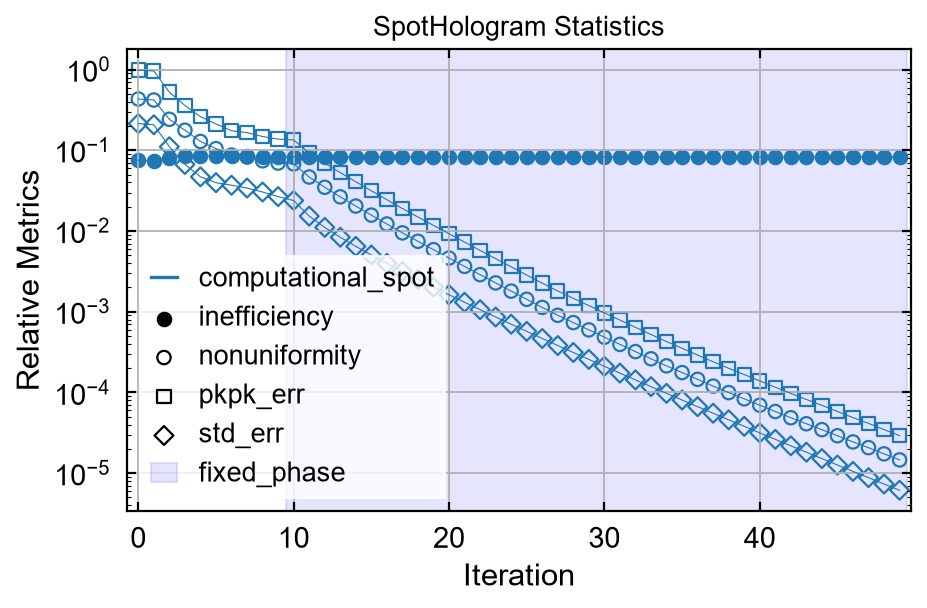


=== Final WGS phase ===
Shape : (1200, 1920)
Min   : 2.861023e-06
Max   : 6.283185


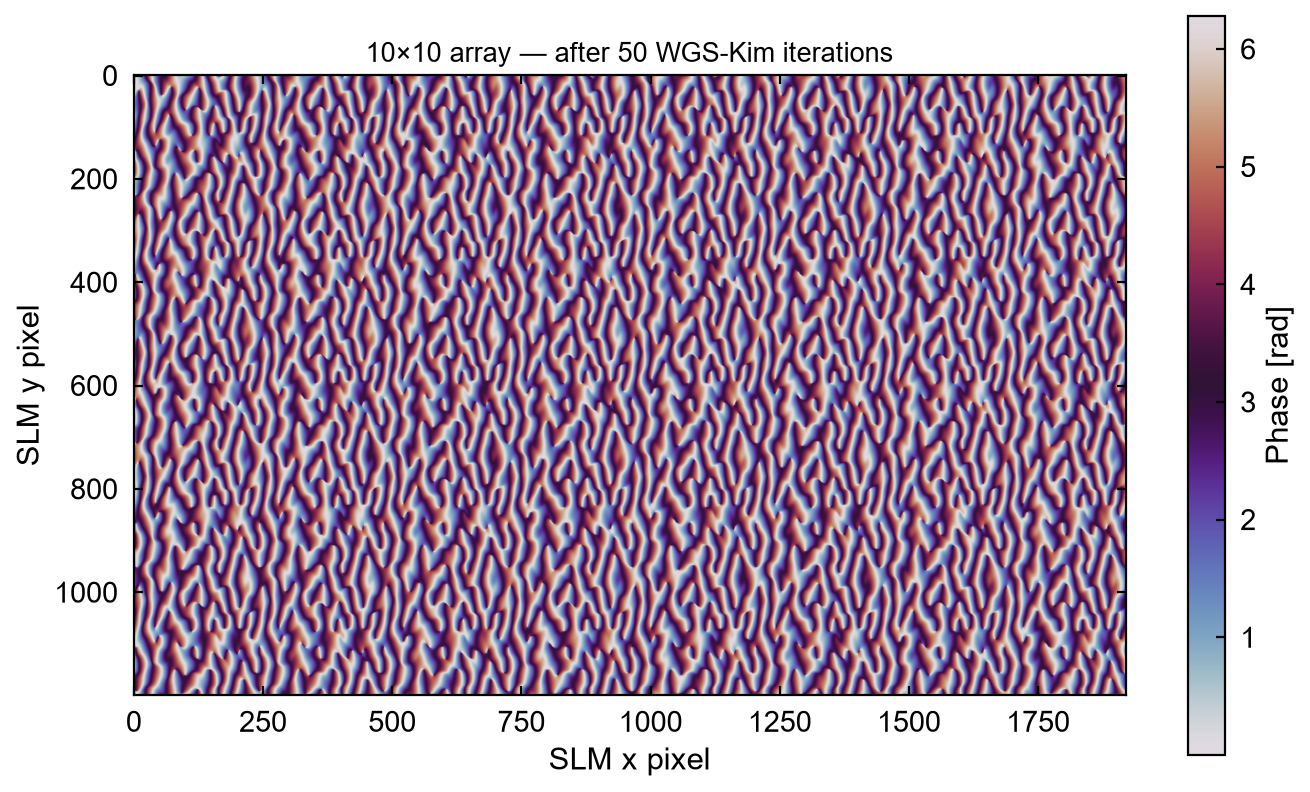

In [29]:
# Cell 8 — 50 iterations of WGS-Kim homogenization
#
# Start from the existing 10x10 GS solution.
# Record convergence for ONLY these 50 WGS iterations.

import copy
import time
import matplotlib.pyplot as plt


# ============================================================
# 1. Copy the existing GS hologram
# ============================================================

holo_10x10_wgs = copy.deepcopy(
    holo_10x10_gs
)


# ============================================================
# 2. Reset optimization history, but KEEP the current GS phase
# ============================================================

holo_10x10_wgs.reset(
    reset_phase=False
)

print("WGS hologram prepared.")
print("Starting from existing GS phase.")


# ============================================================
# 3. Number of WGS iterations
# ============================================================

N_WGS_ITERATIONS = 50


# ============================================================
# 4. Run WGS-Kim
# ============================================================

print(
    f"\nRunning WGS-Kim for "
    f"{N_WGS_ITERATIONS} iterations..."
)

t0 = time.perf_counter()

holo_10x10_wgs.optimize(
    method="WGS-Kim",

    maxiter=N_WGS_ITERATIONS,

    # Homogenize using calculated powers
    # at the requested spot positions.
    feedback="computational_spot",

    # Record spot statistics at every iteration.
    stat_groups=[
        "computational_spot"
    ],

    verbose=2,
)

wgs_time = time.perf_counter() - t0


print(
    f"\n50 WGS iterations completed in "
    f"{wgs_time:.2f} s"
)


# ============================================================
# 5. Plot convergence
# ============================================================

holo_10x10_wgs.plot_stats(
    stat_groups=[
        "computational_spot"
    ]
)

plt.show()


# ============================================================
# 6. Get final phase after 50 WGS iterations
# ============================================================

phase_10x10_wgs = (
    holo_10x10_wgs.get_phase()
)

print("\n=== Final WGS phase ===")
print(
    "Shape :",
    phase_10x10_wgs.shape
)

print(
    "Min   :",
    phase_10x10_wgs.min()
)

print(
    "Max   :",
    phase_10x10_wgs.max()
)


# ============================================================
# 7. Plot final SLM phase
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.imshow(
    phase_10x10_wgs,
    cmap="twilight",
    origin="upper",
)

plt.colorbar(
    label="Phase [rad]"
)

plt.xlabel(
    "SLM x pixel"
)

plt.ylabel(
    "SLM y pixel"
)

plt.title(
    "10×10 array — after 50 WGS-Kim iterations"
)

plt.show()

=== Camera exposure ===
Current exposure : 3.605 ms

Writing final WGS phase to SLM...
SLM write completed in 0.321 s

=== AFTER 50 WGS iterations — ARRAY ONLY ===
Crop shape        : (540, 560)
Peak in array     : 58
Saturated pixels  : 0
Acquisition time  : 0.190 s


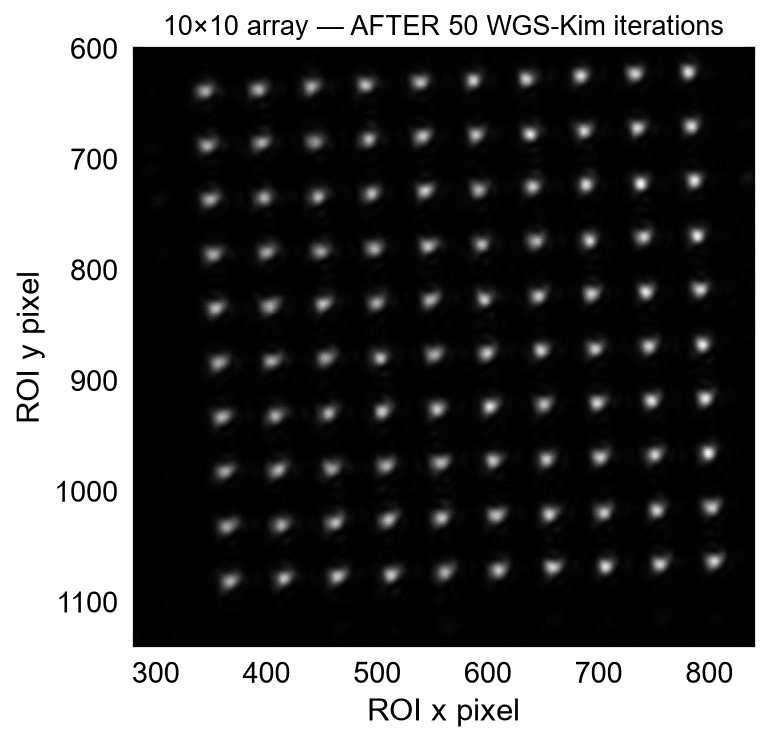

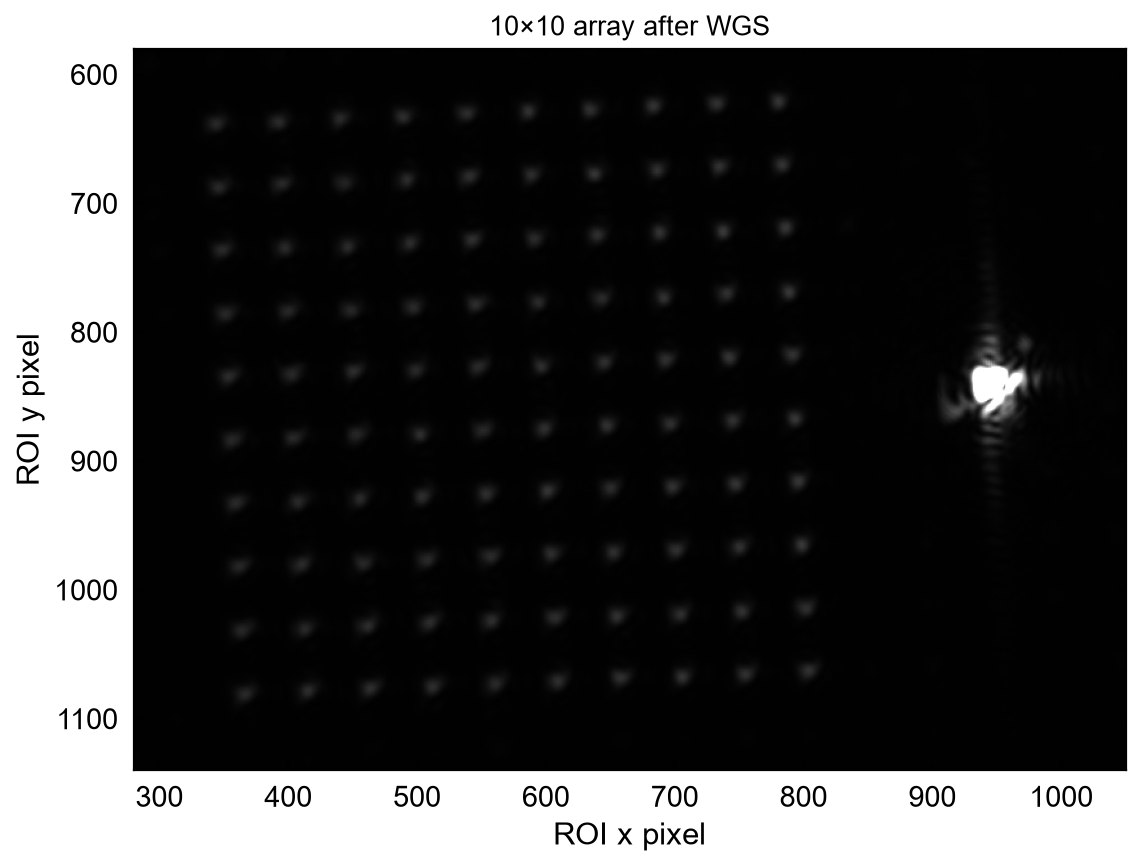

In [32]:
# Cell 9 — Camera image AFTER 50 WGS-Kim iterations
#
# IMPORTANT:
# Keep the same:
#   - laser power
#   - camera exposure
#   - camera gain
#   - camera ROI
#   - software crop
#
# as the BEFORE-WGS image.

import time
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Confirm current camera exposure
# ============================================================

current_exposure_s = cam.get_exposure()

print("=== Camera exposure ===")
print(
    f"Current exposure : "
    f"{current_exposure_s * 1e3:.3f} ms"
)


# ============================================================
# 2. Write final 50-iteration WGS phase to SLM
# ============================================================

print("\nWriting final WGS phase to SLM...")

t0 = time.perf_counter()

slm.set_phase(
    phase_10x10_wgs,
    settle=True,
)

print(
    f"SLM write completed in "
    f"{time.perf_counter() - t0:.3f} s"
)


# ============================================================
# 3. Acquire full camera frame
# ============================================================

t0 = time.perf_counter()

image_10x10_after_full = cam.get_image(
    timeout_s=2,
    transform=False,
)

camera_time = time.perf_counter() - t0


# ============================================================
# 4. Use EXACTLY the same array crop as BEFORE
# ============================================================

image_10x10_after = image_10x10_after_full[
    ARRAY_Y0:ARRAY_Y1,
    ARRAY_X0:ARRAY_X1
]


# ============================================================
# 5. Array-only diagnostics
# ============================================================

print("\n=== AFTER 50 WGS iterations — ARRAY ONLY ===")

print(
    "Crop shape        :",
    image_10x10_after.shape
)

print(
    "Peak in array     :",
    image_10x10_after.max()
)

print(
    "Saturated pixels  :",
    np.count_nonzero(
        image_10x10_after == 255
    )
)

print(
    f"Acquisition time  : "
    f"{camera_time:.3f} s"
)


# ============================================================
# 6. Plot AFTER-WGS image
# ============================================================

plt.figure(figsize=(5,5))

plt.imshow(
    image_10x10_after,
    cmap="gray",
    origin="upper",

    # Preserve original ROI coordinate labels
    extent=(
        ARRAY_X0,
        ARRAY_X1,
        ARRAY_Y1,
        ARRAY_Y0,
    ),
)

plt.xlabel("ROI x pixel")
plt.ylabel("ROI y pixel")

plt.title(
    "10×10 array — AFTER 50 WGS-Kim iterations"
)

plt.show()

# Display a wider region of the SAME camera image
# No change to the camera hardware ROI.

plt.figure(figsize=(8, 6.5))

plt.imshow(
    image_10x10_after_full,
    cmap="gray",
    origin="upper",
)

# Wider DISPLAY window: includes array + zeroth order
plt.xlim(280, 1050)
plt.ylim(1140, 580)

plt.xlabel("ROI x pixel")
plt.ylabel("ROI y pixel")
plt.title("10×10 array after WGS")

plt.show()

In [31]:
# Check actual discrete knm spacings of the current 10x10 target

x_positions = np.sort(
    np.unique(holo_10x10_gs.spot_knm_rounded[0])
)

y_positions = np.sort(
    np.unique(holo_10x10_gs.spot_knm_rounded[1])
)

print("x positions:")
print(x_positions)

print("\nx spacings:")
print(np.diff(x_positions))

print("\ny positions:")
print(y_positions)

print("\ny spacings:")
print(np.diff(y_positions))

x positions:
[ 985  993 1001 1009 1017 1025 1033 1041 1049 1057]

x spacings:
[8 8 8 8 8 8 8 8 8]

y positions:
[578 583 588 593 598 603 608 613 618 623]

y spacings:
[5 5 5 5 5 5 5 5 5]
